**0. Описать задачу**

**Задача:** Прогнозирование оттока клиентов банка. Определить клиентов, которые с высокой вероятностью закроют свои счета и уйдут из банка, на основе персональных данных клиентов(пол, возраст, уровень дохода, образование и т.д.), данных об активности(транзакции, кредитный лимит и тд) и данных банковского профиля(тип карты,количество транзакций за год и тп).

Бинарная классификация: предсказать, уйдет клиент (Attrition_Flag = 'Attrited Customer') или останется (Attrition_Flag = 'Existing Customer').



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import kagglehub

**1.Прочитать данные**

In [2]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/ML/BankChurners.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data.shape

(10127, 23)

Владелец датасета реккомендует удалить последние два столбца (NAIVE BAYES CLAS…), т.к. они судя по всему остались после его работы с датасетом и не несут ценности для нашей классификации.

In [4]:
data = data.iloc[:, :-2]
data.shape

(10127, 21)

In [5]:
data

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

**2. Разбить данные на тестовую и обучающую выборки**

In [7]:
from sklearn.model_selection import train_test_split

X = data.drop('Attrition_Flag', axis=1)
y = data['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Размер X_train:", X_train.shape)
print("Размер y_train:", y_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (8101, 20)
Размер y_train: (8101,)
Размер X_test: (2026, 20)
Размер y_test: (2026,)


**3. Визуализация данных и вычисление основных характеристик**

In [8]:
print(X_train.describe())

          CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
count  8.101000e+03   8101.000000      8101.000000     8101.000000   
mean   7.392038e+08     46.327120         2.350574       35.938279   
std    3.688754e+07      7.985768         1.296832        7.957442   
min    7.080821e+08     26.000000         0.000000       13.000000   
25%    7.130198e+08     41.000000         1.000000       32.000000   
50%    7.179283e+08     46.000000         2.000000       36.000000   
75%    7.731774e+08     52.000000         3.000000       40.000000   
max    8.283431e+08     73.000000         5.000000       56.000000   

       Total_Relationship_Count  Months_Inactive_12_mon  \
count               8101.000000             8101.000000   
mean                   3.820886                2.335514   
std                    1.547005                1.002347   
min                    1.000000                0.000000   
25%                    3.000000                2.000000   
50%            

**Целевая переменная:** Attrition_Flag — статус клиента:

    Existing Customer — действующий клиент (остался в банке)
    Attrited Customer — ушедший клиент (прекратил сотрудничество с банком)
**Числовые признаки:**

    Customer_Age - Возраст клиента (в годах)
    Dependent_count - Количество иждивенцев (детей, членов семьи, находящихся на содержании клиента)
    Months_on_book - Количество месяцев обслуживания клиента в банке
    Months_Inactive_12_mon - Количество месяцев без активности за последние 12 месяцев
    Contacts_Count_12_mon - Количество взаимодействий клиента с банком за последние 12 месяцев
    Credit_Limit - Установленный кредитный лимит клиента
    Total_Revolving_Bal - Общий остаток задолженности по вращающемуся кредиту (revolving balance)
    Avg_Open_To_Buy - Средняя сумма доступного кредитного лимита (разница между лимитом и задолженностью)
    Avg_Utilization_Ratio - Среднее отношение используемого кредита к общему лимиту (индикатор нагрузки по кредиту)
    Total_Relationship_Count - Общее количество продуктов банка, которыми пользуется клиент (например, кредитная карта, вклад, ипотека и т.д.)
    Total_Trans_Amt - Общая сумма транзакций за последние 12 месяцев
    Total_Trans_Ct - Общее количество транзакций за последние 12 месяцев
    Total_Amt_Chng_Q4_Q1 - Изменение общей суммы транзакций между 4-м и 1-м кварталом (показатель активности)
    Total_Ct_Chng_Q4_Q1 - Изменение количества транзакций между 4-м и 1-м кварталом (показатель активности)
    
**Категориальные признаки:**

    Gender - Пол клиента (Male, Female)
    Education_Level - Уровень образования (High School, Graduate, College, Uneducated, Doctorate, и т.п.)
    Marital_Status - Семейное положение (Married, Single, Divorced, Unknown)
    Income_Category - Категория годового дохода (< $40K, $40K - $60K, $60K - $80K, $80K - $120K, $120K +, Unknown)
    Card_Category - Тип кредитной карты (Blue, Silver, Gold, Platinum)

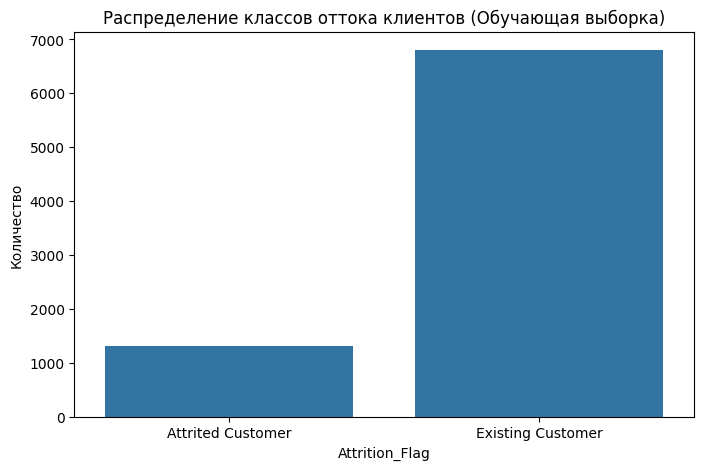

Доля каждого класса (%):
Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64


In [9]:
train_data_viz = X_train.copy()
train_data_viz['Attrition_Flag'] = y_train

plt.figure(figsize=(8, 5))
sns.countplot(x=train_data_viz['Attrition_Flag'])
plt.title('Распределение классов оттока клиентов (Обучающая выборка)')
plt.ylabel('Количество')
plt.show()

print("Доля каждого класса (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

количество ушедших клиентов 16% значительно меньше количества оставшихся, класс несбалансирован

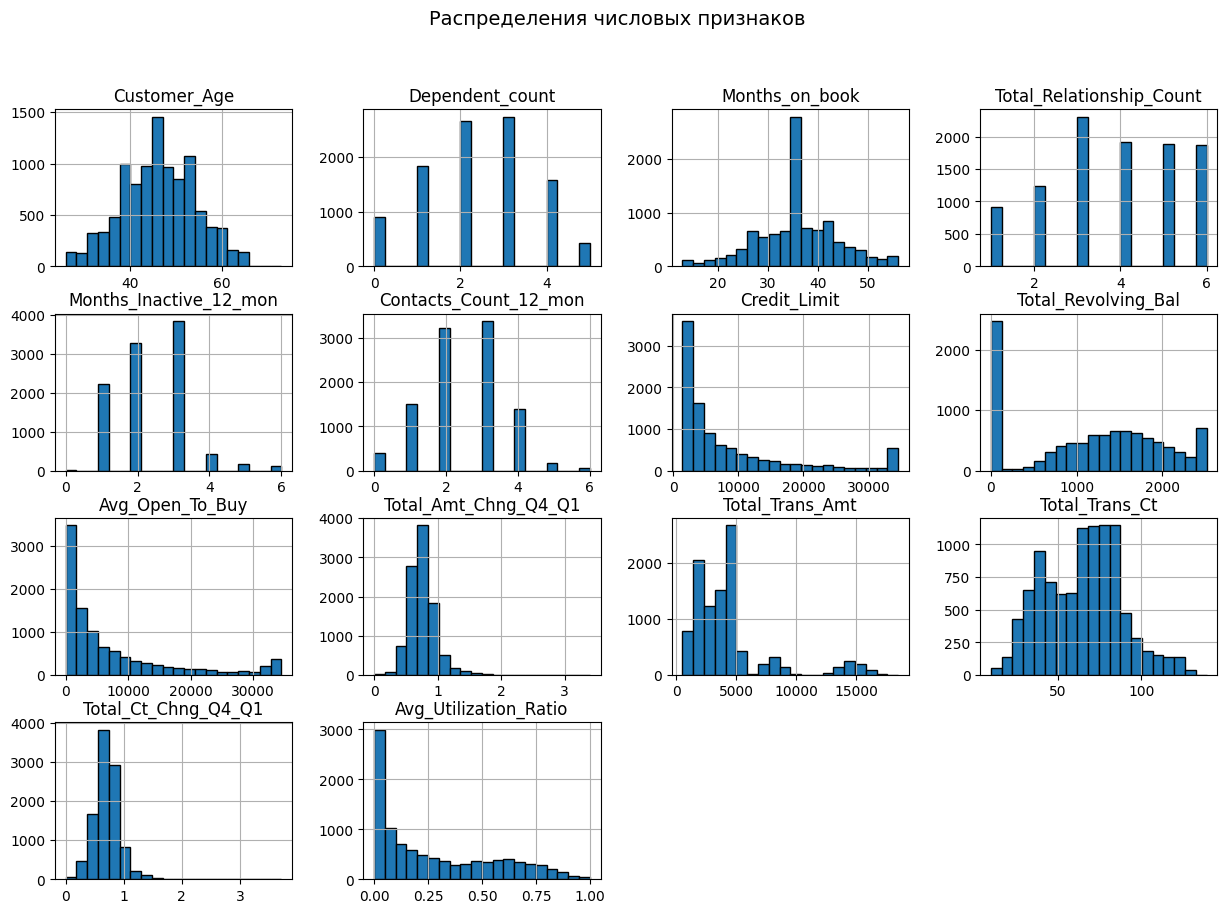

In [10]:
data_for_viz = data.drop(['CLIENTNUM'], axis=1)
data_for_viz.hist(figsize=(15, 10), bins=20, edgecolor="black")
plt.suptitle("Распределения числовых признаков", fontsize=14)
plt.show()

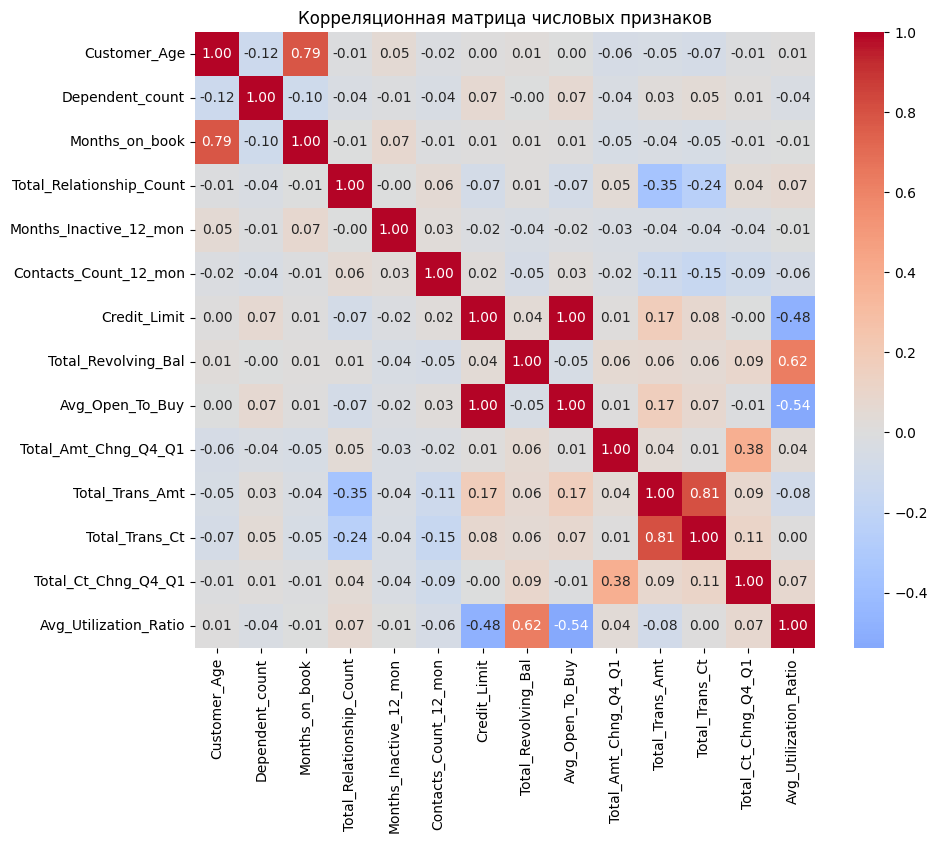

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(data_for_viz.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

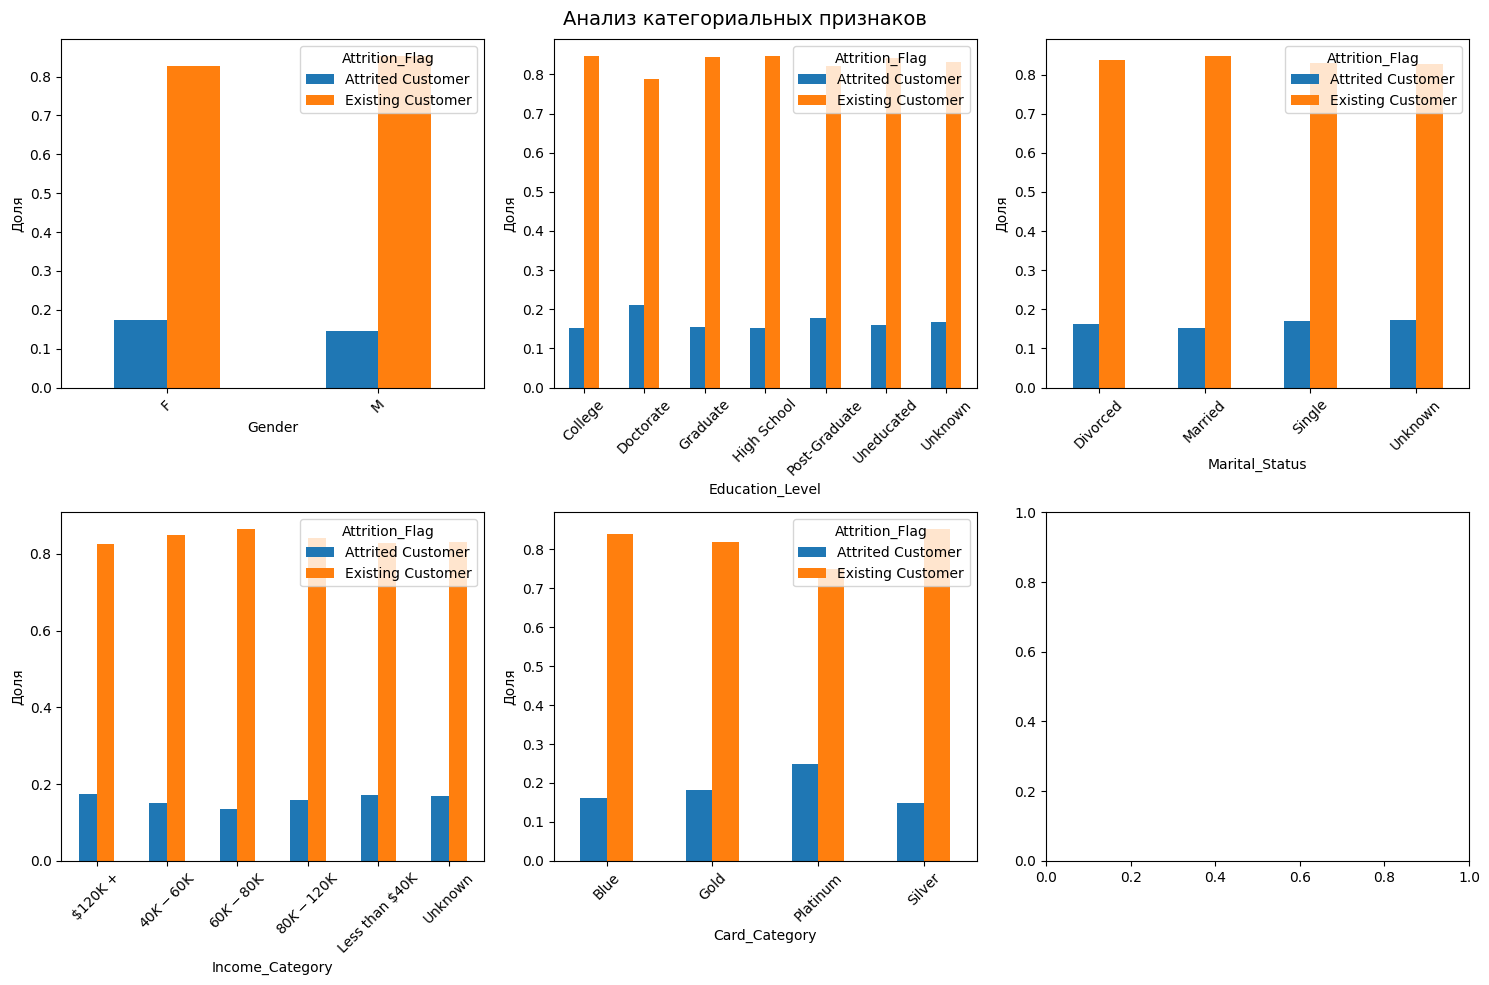

In [12]:
categorical_cols = data_for_viz.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols[1:]):
    if i < len(axes):

        ct = pd.crosstab(data_for_viz[col], data_for_viz['Attrition_Flag'], normalize='index')
        ct.plot(kind='bar', ax=axes[i])
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Доля')
        axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Анализ категориальных признаков", fontsize=14)
plt.tight_layout()
plt.show()

**4. Обработка пропущенных значений**

In [13]:
print("Пропущенные значения в обучающей выборке:")
print(X_train.isnull().sum())

print("\nПропущенные значения в тестовой выборке:")
print(X_test.isnull().sum())

print("Пропущенных значений нет!")

Пропущенные значения в обучающей выборке:
CLIENTNUM                   0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

Пропущенные значения в тестовой выборке:
CLIENTNUM                   0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Mon

**5. Обработка категориальных признаков**

In [14]:
X_train.Gender = X_train.Gender.replace(to_replace=['M', 'F'], value=[1, 0])
X_test.Gender = X_test.Gender.replace(to_replace=['M', 'F'], value=[1, 0])

/tmp/ipython-input-207434185.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train.Gender = X_train.Gender.replace(to_replace=['M', 'F'], value=[1, 0])
/tmp/ipython-input-207434185.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test.Gender = X_test.Gender.replace(to_replace=['M', 'F'], value=[1, 0])


In [15]:
non_bin_cols = ['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

In [16]:
X_train_encoded = pd.get_dummies(X_train[non_bin_cols], dtype = int)
X_test_encoded = pd.get_dummies(X_test[non_bin_cols], dtype = int)

print(f"Размер после encoding: {X_train_encoded.shape}")

Размер после encoding: (8101, 21)


In [17]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8101 entries, 1602 to 3640
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Education_Level_College         8101 non-null   int64
 1   Education_Level_Doctorate       8101 non-null   int64
 2   Education_Level_Graduate        8101 non-null   int64
 3   Education_Level_High School     8101 non-null   int64
 4   Education_Level_Post-Graduate   8101 non-null   int64
 5   Education_Level_Uneducated      8101 non-null   int64
 6   Education_Level_Unknown         8101 non-null   int64
 7   Marital_Status_Divorced         8101 non-null   int64
 8   Marital_Status_Married          8101 non-null   int64
 9   Marital_Status_Single           8101 non-null   int64
 10  Marital_Status_Unknown          8101 non-null   int64
 11  Income_Category_$120K +         8101 non-null   int64
 12  Income_Category_$40K - $60K     8101 non-null   int64
 13  Incom

**6. Нормализация**

In [18]:
numerical_columns   = [c for c in X.columns if X[c].dtype.name != 'object']


In [19]:
X_train_numerical = X_train[numerical_columns]
X_train_numerical.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,8.101000e+03,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000
mean,7.392038e+08,46.327120,2.350574,35.938279,3.820886,2.335514,2.449944,8636.210838,1162.422540,7473.788298,0.759994,4393.027034,64.752253,0.711916,0.274138
std,3.688754e+07,7.985768,1.296832,7.957442,1.547005,1.002347,1.103919,9107.980541,814.680244,9107.090992,0.219483,3396.981611,23.486066,0.238334,0.274709
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,530.000000,10.000000,0.000000,0.000000
25%,7.130198e+08,41.000000,1.000000,32.000000,3.000000,2.000000,2.000000,2553.000000,357.000000,1335.000000,0.631000,2151.000000,45.000000,0.583000,0.023000
50%,7.179283e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1279.000000,3451.000000,0.738000,3890.000000,67.000000,0.700000,0.176000
75%,7.731774e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.000000,1781.000000,9885.000000,0.860000,4730.000000,80.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.571000,0.999000


In [20]:
X_train_numerical = (X_train_numerical - X_train_numerical.mean(axis = 0))/X_train_numerical.std(axis = 0)
X_train_numerical.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03
mean,1.230578e-15,1.929631e-16,1.087610e-16,-4.429380e-16,8.946471e-17,1.320043e-16,2.455894e-17,-8.244787e-17,-4.648656e-17,-1.403368e-17,4.631114e-16,-1.008671e-16,1.872619e-16,1.425296e-16,-6.841419e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-8.436905e-01,-2.545418e+00,-1.812550e+00,-2.882620e+00,-1.823451e+00,-2.330045e+00,-2.219316e+00,-7.902861e-01,-1.426845e+00,-8.203265e-01,-3.462662e+00,-1.137194e+00,-2.331265e+00,-2.987059e+00,-9.979193e-01
25%,-7.098323e-01,-6.670768e-01,-1.041441e+00,-4.949177e-01,-5.306296e-01,-3.347284e-01,-4.075885e-01,-6.678990e-01,-9.886364e-01,-6.740669e-01,-5.877190e-01,-6.600056e-01,-8.410201e-01,-5.409066e-01,-9.141945e-01
50%,-5.767650e-01,-4.096289e-02,-2.703310e-01,7.756359e-03,1.157810e-01,-3.347284e-01,-4.075885e-01,-4.487505e-01,1.430960e-01,-4.417204e-01,-1.002087e-01,-1.480806e-01,9.570557e-02,-4.999793e-02,-3.572425e-01
75%,9.210049e-01,7.103738e-01,5.007787e-01,5.104305e-01,7.621915e-01,6.629297e-01,4.982755e-01,2.668856e-01,7.592886e-01,2.647620e-01,4.556440e-01,9.919776e-02,6.492253e-01,4.451066e-01,8.331061e-01
max,2.416516e+00,3.340052e+00,2.042998e+00,2.521127e+00,1.408602e+00,3.655904e+00,3.215867e+00,2.841441e+00,1.662711e+00,2.969358e+00,1.201465e+01,4.148086e+00,3.161353e+00,1.199615e+01,2.638650e+00


In [21]:
X_test_numerical = X_test[numerical_columns]
X_test_numerical.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,2.026000e+03,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
mean,7.390731e+08,46.321323,2.328727,35.888944,3.779368,2.363771,2.476802,8614.931441,1164.379566,7450.551876,0.759727,4448.307009,65.284304,0.713447,0.277915
std,3.697759e+07,8.141763,1.307352,8.103101,1.583616,1.043002,1.115416,9013.794842,816.413573,9027.001215,0.218154,3398.198471,23.419484,0.237149,0.279632
min,7.080992e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,14.000000,0.061000,510.000000,10.000000,0.059000,0.000000
25%,7.131207e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2563.250000,419.000000,1284.500000,0.630000,2177.750000,45.000000,0.578000,0.022250
50%,7.179016e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4533.000000,1262.500000,3538.000000,0.731000,3927.000000,67.000000,0.704000,0.175000
75%,7.728738e+08,52.000000,3.000000,41.000000,5.000000,3.000000,3.000000,11063.500000,1795.500000,9815.000000,0.854000,4776.000000,81.000000,0.821000,0.502000
max,8.279847e+08,68.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,2.282000,17258.000000,138.000000,3.714000,0.992000


In [22]:
X_test_numerical = (X_test_numerical - X_test_numerical.mean(axis = 0))/X_test_numerical.std(axis = 0)
X_test_numerical.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03
mean,1.201627e-15,3.068731e-16,1.727257e-16,2.051666e-16,3.857833e-17,1.508062e-16,-9.819939e-17,-2.981053e-17,-5.085326e-17,-4.383901e-17,3.016124e-16,-2.630341e-17,-1.823703e-16,-5.436038e-16,-1.446687e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-8.376393e-01,-2.495936e+00,-1.781254e+00,-2.824714e+00,-1.755077e+00,-2.266316e+00,-2.220518e+00,-7.961831e-01,-1.426213e+00,-8.238120e-01,-3.202903e+00,-1.158940e+00,-2.360612e+00,-2.759645e+00,-9.938612e-01
25%,-7.018410e-01,-6.535836e-01,-1.016349e+00,-6.033423e-01,-4.921446e-01,-3.487732e-01,-4.274652e-01,-6.713800e-01,-9.129926e-01,-6.830676e-01,-5.946573e-01,-6.681649e-01,-8.661294e-01,-5.711463e-01,-9.142922e-01
50%,-5.725493e-01,-3.946600e-02,-2.514446e-01,1.370540e-02,1.393215e-01,-3.487732e-01,-4.274652e-01,-4.528538e-01,1.201847e-01,-4.334276e-01,-1.316822e-01,-1.534069e-01,7.325934e-02,-3.983444e-02,-3.680380e-01
75%,9.140857e-01,6.974751e-01,5.134603e-01,6.307531e-01,7.707876e-01,6.099982e-01,4.690612e-01,2.716468e-01,7.730401e-01,2.619306e-01,4.321389e-01,9.643139e-02,6.710522e-01,4.535266e-01,8.013572e-01
max,2.404472e+00,2.662651e+00,2.043270e+00,2.481896e+00,1.402254e+00,3.486312e+00,3.158641e+00,2.873492e+00,1.656783e+00,2.998277e+00,6.977964e+00,3.769554e+00,3.104923e+00,1.265262e+01,2.553662e+00


In [23]:
X_test = pd.concat((X_test_numerical, X_test.Gender, X_test_encoded), axis = 1)
X_train = pd.concat((X_train_numerical, X_train.Gender, X_train_encoded), axis = 1)

In [24]:
X_test.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
count,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,2.026000e+03,...,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
mean,1.201627e-15,3.068731e-16,1.727257e-16,2.051666e-16,3.857833e-17,1.508062e-16,-9.819939e-17,-2.981053e-17,-5.085326e-17,-4.383901e-17,...,0.062685,0.171767,0.147088,0.143633,0.356861,0.117966,0.935341,0.012340,0.002962,0.049358
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.242456,0.377271,0.354281,0.350804,0.479192,0.322648,0.245985,0.110423,0.054352,0.216669
min,-8.376393e-01,-2.495936e+00,-1.781254e+00,-2.824714e+00,-1.755077e+00,-2.266316e+00,-2.220518e+00,-7.961831e-01,-1.426213e+00,-8.238120e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.018410e-01,-6.535836e-01,-1.016349e+00,-6.033423e-01,-4.921446e-01,-3.487732e-01,-4.274652e-01,-6.713800e-01,-9.129926e-01,-6.830676e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,-5.725493e-01,-3.946600e-02,-2.514446e-01,1.370540e-02,1.393215e-01,-3.487732e-01,-4.274652e-01,-4.528538e-01,1.201847e-01,-4.334276e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,9.140857e-01,6.974751e-01,5.134603e-01,6.307531e-01,7.707876e-01,6.099982e-01,4.690612e-01,2.716468e-01,7.730401e-01,2.619306e-01,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,2.404472e+00,2.662651e+00,2.043270e+00,2.481896e+00,1.402254e+00,3.486312e+00,3.158641e+00,2.873492e+00,1.656783e+00,2.998277e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
X_train.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
count,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,8.101000e+03,...,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000
mean,1.230578e-15,1.929631e-16,1.087610e-16,-4.429380e-16,8.946471e-17,1.320043e-16,2.455894e-17,-8.244787e-17,-4.648656e-17,-1.403368e-17,...,0.074065,0.178003,0.136279,0.153561,0.350327,0.107764,0.930873,0.011233,0.001728,0.056166
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.261893,0.382539,0.343106,0.360550,0.477102,0.310102,0.253686,0.105396,0.041538,0.230256
min,-8.436905e-01,-2.545418e+00,-1.812550e+00,-2.882620e+00,-1.823451e+00,-2.330045e+00,-2.219316e+00,-7.902861e-01,-1.426845e+00,-8.203265e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.098323e-01,-6.670768e-01,-1.041441e+00,-4.949177e-01,-5.306296e-01,-3.347284e-01,-4.075885e-01,-6.678990e-01,-9.886364e-01,-6.740669e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,-5.767650e-01,-4.096289e-02,-2.703310e-01,7.756359e-03,1.157810e-01,-3.347284e-01,-4.075885e-01,-4.487505e-01,1.430960e-01,-4.417204e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,9.210049e-01,7.103738e-01,5.007787e-01,5.104305e-01,7.621915e-01,6.629297e-01,4.982755e-01,2.668856e-01,7.592886e-01,2.647620e-01,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,2.416516e+00,3.340052e+00,2.042998e+00,2.521127e+00,1.408602e+00,3.655904e+00,3.215867e+00,2.841441e+00,1.662711e+00,2.969358e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**7. Классификация**

метод ближайших соседей



Результаты:
Accuracy: 0.9126

Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       0.83      0.58      0.68       325
Existing Customer       0.92      0.98      0.95      1701

         accuracy                           0.91      2026
        macro avg       0.88      0.78      0.81      2026
     weighted avg       0.91      0.91      0.91      2026



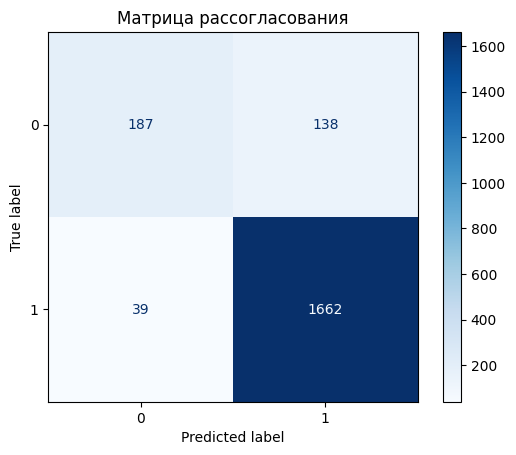

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

print(f"\nРезультаты:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title(f'Матрица рассогласования')
plt.show()

подбор оптимальных параметров

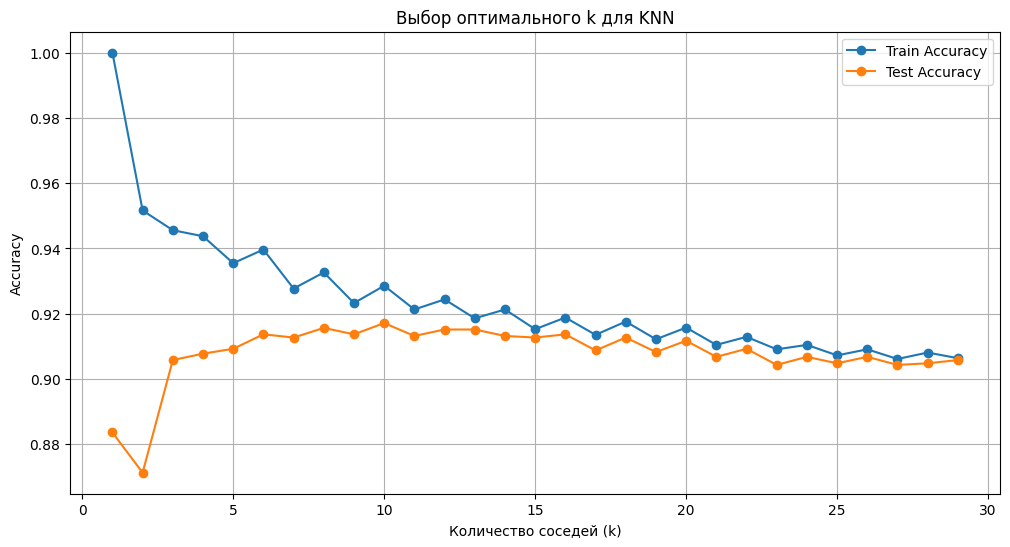

Оптимальное количество соседей: 10
Лучшая accuracy на тесте: 0.9171

Оптимальный KNN Результаты:
Accuracy: 0.9171

Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       0.82      0.62      0.71       325
Existing Customer       0.93      0.97      0.95      1701

         accuracy                           0.92      2026
        macro avg       0.87      0.80      0.83      2026
     weighted avg       0.91      0.92      0.91      2026



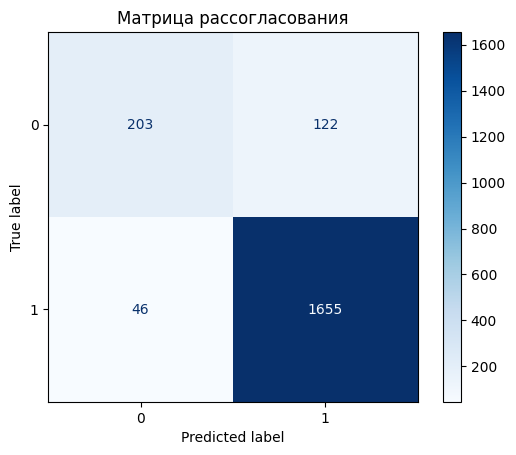

In [27]:

def evaluate_model(y_true, y_pred, dataset_name):
    print(f"\n{dataset_name} Результаты:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f'Матрица рассогласования')
    plt.show()



train_scores = []
test_scores = []
k_values = range(1, 30)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)

    train_scores.append(accuracy_score(y_train, knn_temp.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn_temp.predict(X_test)))

# Визуализация результатов
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, 'o-', label='Train Accuracy')
plt.plot(k_values, test_scores, 'o-', label='Test Accuracy')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Accuracy')
plt.title('Выбор оптимального k для KNN')
plt.legend()
plt.grid(True)
plt.show()


optimal_k = k_values[np.argmax(test_scores)]
print(f"Оптимальное количество соседей: {optimal_k}")
print(f"Лучшая accuracy на тесте: {max(test_scores):.4f}")

#модель с оптимальным k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

y_pred_optimal = knn_optimal.predict(X_test)
evaluate_model(y_test, y_pred_optimal, "Оптимальный KNN")